# 🎯 4. Tools and Function Calling

Tools are what separate an agent from a chatbot. Without tools, an LLM can only generate text. With tools, it can **act** in the real world.

In this notebook:

1. **Tool abstraction** — what makes a good tool?
2. **Function schemas** — how LLMs understand tools
3. **OpenAI function calling** — the lifecycle in detail
4. **LangChain @tool decorator** — defining tools cleanly
5. **LangGraph ToolNode** — prebuilt tool execution
6. **Building a multi-tool agent** — combining everything

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL   = "gpt-4o-mini"

print(f'Model: {LLM_MODEL}')
print(f'API key configured: {bool(os.getenv("OPENAI_API_KEY"))}')

Model: gpt-4o-mini
API key configured: True


## 4.1 What Makes a Good Tool?

A tool is a **function** that an agent can invoke to interact with the external world. But not every function makes a good tool.

### Anatomy of a Tool

Every tool needs three things:

| Component | Purpose | Example |
|-----------|---------|--------|
| **Name** | Unique identifier | `search_web` |
| **Description** | What the tool does (the LLM reads this!) | `Search the web for information about a topic` |
| **Parameters** | Typed inputs with descriptions | `{query: string, max_results: int}` |

### Good vs. Bad Tool Design

| ❌ Bad | ✅ Good | Why |
|--------|---------|-----|
| `do_stuff(x)` | `search_web(query: str)` | Clear name, typed params |
| No description | `"Search the web for current information"` | LLM needs to know when to use it |
| Returns raw HTML | Returns clean text summary | Agent needs processable output |
| Does 5 things | Does 1 thing well | Single responsibility |

> **Rule of thumb**: Write tool descriptions as if explaining to a smart colleague who has never seen the tool before. The LLM uses this description to decide *when* and *how* to use the tool.

## 4.2 Building a Tool Registry from Scratch

In [ ]:
from typing import Callable, Any
from dataclasses import dataclass, field

@dataclass
class Tool:
    """A tool that an agent can use"""
    name: str
    description: str
    parameters: dict
    function: Callable

    def run(self, **kwargs) -> str:
        """Execute the tool with given arguments"""
        try:
            result = self.function(**kwargs)
            return str(result)
        except Exception as e:
            return f"Error executing {self.name}: {e}"
    
    def to_openai_schema(self) -> dict:
        """"Convert to OpenAI function calling format"""
        return {
            "type": 'function',
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.parameters
            }
        }

class ToolRegistry:
    """Registry that manages all available tools"""
    def __init__(self):
        self._tools : dict[str, Tool] = {} # ειχαμε = αντί για :
    
    def register(self, tool: Tool):
        self._tools[tool.name] = tool
    
    def get(self, name: str) -> Tool | None:
        return self._tools.get(name)
    
    def get_schemas(self) -> list[dict]:
        return [t.to_openai_schema() for t in self._tools.values()]
    
    def execute(self, name: str, **kwargs) -> str:
        tool = self.get(name)
        if not tool:
            return f"Uknown tool: {name}"
        return tool.run(**kwargs)

In [13]:
import math
from datetime import datetime

registry = ToolRegistry()

registry.register(Tool(
    name='calculate',
    description='Evaluate a mathematical expression. Supports +, -, *, /, sqrt, pow.',
    parameters={
        'type': 'object',
        'properties': {'expression': {'type': 'string', 'description': 'Math expression to evaluate'}},
        'required': ['expression']
    },
    function=lambda expression: eval(expression, {'__builtins__': {}}, {'sqrt': math.sqrt, 'pow': pow, 'pi': math.pi})
))

def get_current_time() -> str:
    """Get the current date and time."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

registry.register(Tool(
    name='get_current_time',
    description='Get the current date and time.',
    parameters={'type': 'object', 'properties': {}, 'required': []},
    function=get_current_time
))

registry.register(Tool(
    name='search_knowledge',
    description='Search a knowledge base for information about a topic.',
    parameters={
        'type': 'object',
        'properties': {'query': {'type': 'string', 'description': 'Search query'}},
        'required': ['query']
    },
    function=lambda query: f'Knowledge base result for "{query}": This is a simulated search result. In production, this would query a vector database.'
))

print(f'Registered tools: {list(registry._tools.keys())}')
print(f'\nTest calculate: {registry.execute("calculate", expression="sqrt(144) + pow(2, 10)")}')
print(f'Test time: {registry.execute("get_current_time")}')


Registered tools: ['calculate', 'get_current_time', 'search_knowledge']

Test calculate: 1036.0
Test time: 2026-05-19 20:05:35


## 4.3 OpenAI Function Calling — The Full Lifecycle

The function calling lifecycle has four steps:

```
1. DEFINE  → Send tool schemas to the LLM
2. SELECT  → LLM chooses which tool to call (returns tool_calls)
3. EXECUTE → Your code runs the actual function
4. RESPOND → Send tool results back to LLM for final answer
```

<img src="images/func-call-lifecycle.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

Let's see this in action with our registry:

In [14]:
from openai import OpenAI
import json

client = OpenAI()

def agent_with_registry(query: str) -> str:
    """Agent that uses our ToolRegistry for function calling."""
    messages = [
        {'role': 'system', 'content': 'You are a helpful assistant. Use tools when needed.'},
        {'role': 'user', 'content': query}
    ]
    
    for step in range(5):
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=messages,
            tools=registry.get_schemas(),  # Step 1: DEFINE
            temperature=0
        )
        
        choice = response.choices[0]
        
        if choice.finish_reason == 'tool_calls':  # Step 2: SELECT
            messages.append(choice.message)
            
            for tc in choice.message.tool_calls:
                args = json.loads(tc.function.arguments)
                print(f'  Tool: {tc.function.name}({args})')
                
                result = registry.execute(tc.function.name, **args)  # Step 3: EXECUTE
                print(f'  Result: {result}')
                
                messages.append({  # Step 4: RESPOND
                    'role': 'tool',
                    'tool_call_id': tc.id,
                    'content': str(result)
                })
        else:
            return choice.message.content
    
    return 'Max steps reached.'

# Test
print(agent_with_registry('What time is it, and what is sqrt(256) * 3? (NO LaTeX)'))

  Tool: get_current_time({})
  Result: 2026-05-19 20:18:36
  Tool: calculate({'expression': 'sqrt(256) * 3'})
  Result: 48.0
The current time is 20:18:36, and the result of sqrt(256) * 3 is 48.


## 4.4 LangChain's @tool Decorator

LangChain simplifies tool creation with the `@tool` decorator. It automatically:
- Extracts the function name
- Uses the docstring as the description
- Infers parameter types from type hints

In [17]:
from langchain_core.tools import tool

@tool(description="Who called me?")
def multiply(a: float, b: float) -> float:
    # """Multiply two numbers together"""
    return a * b

@tool
def add(a: float, b: float) -> float:
    """Add two numbers together"""
    return a + b

@tool
def web_search(query: str) -> str:
    """Search the web for the information about a topic. Returns a summary."""
    return f'Search results for "{query}": [Simulated] AI agents are systems that use LLMs to reason and take actions autonomously.'

print(f"Tool name: {multiply.name}")
print(f"Description: {multiply.description}")
print(f"Schema: {json.dumps(multiply.args_schema.model_json_schema(), indent=2)}")


Tool name: multiply
Description: Who called me?
Schema: {
  "properties": {
    "a": {
      "title": "A",
      "type": "number"
    },
    "b": {
      "title": "B",
      "type": "number"
    }
  },
  "required": [
    "a",
    "b"
  ],
  "title": "multiply",
  "type": "object"
}


## 4.5 LangGraph ToolNode — Agent with Automatic Tool Execution

LangGraph provides a `ToolNode` that automatically:
1. Reads tool calls from the LLM's response
2. Executes the matching tool
3. Returns the result as a message

<img src="images/tool-node.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

### This is the **production pattern** for tool-using agents:

<img src="images/prod-pattern.png" width="40%" style="border-radius:10px;margin:12px 0;"/>

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from IPython.display import display, Markdown

# Tools
tools = [multiply, add, web_search]

# LLM client - tool binding
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
llm_with_tools = llm.bind_tools(tools)

# Node: Call the LLM
def call_model(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

# Router: should we call tools or finish ?
def should_continue(state: MessagesState) -> dict:
    last = state['messages'][-1]
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return 'tools'
    return END

# Build graph
tool_graph = StateGraph(MessagesState)

# Add nodes
tool_graph.add_node('agent', call_model)
tool_graph.add_node('tools', ToolNode(tools))

# Add edges
tool_graph.add_edge(START, 'agent')
tool_graph.add_conditional_edges('agent', should_continue, ['tools', END])
tool_graph.add_edge('tools', 'agent')

tool_app = tool_graph.compile()
print("Tool App is ready!")

Tool App is ready!


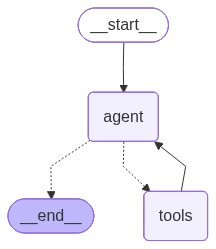

In [21]:
from IPython.display import Image, display

display(Image(tool_app.get_graph().draw_mermaid_png()))

In [22]:
result = tool_app.invoke({
    "messages": [HumanMessage(content="What is 15 *23, and what is 100 + 250? Also, search for info about React agents")]
})

for msg in result['messages']:
    role = msg.__class__.__name__
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tc in msg.tool_calls:
            display(Markdown(f' - Tool Call: {tc["name"]}({tc["args"]})'))
    elif hasattr(msg, 'content') and msg.content:
        display(Markdown(f'#### {role}: {msg.content}'))

#### HumanMessage: What is 15 *23, and what is 100 + 250? Also, search for info about React agents

 - Tool Call: multiply({'a': 15, 'b': 23})

 - Tool Call: add({'a': 100, 'b': 250})

 - Tool Call: web_search({'query': 'React agents'})

#### ToolMessage: 345.0

#### ToolMessage: 350.0

#### ToolMessage: Search results for "React agents": [Simulated] AI agents are systems that use LLMs to reason and take actions autonomously.

#### AIMessage: The results of your calculations are as follows:

- \( 15 \times 23 = 345 \)
- \( 100 + 250 = 350 \)

Regarding your search for information about React agents, it appears that React agents are simulated AI agents that utilize large language models (LLMs) to reason and take actions autonomously.

## 4.6 Error Handling in Tool Execution

Tools **will** fail in production. Good agents handle errors gracefully:

| Error Type | Example | Handling |
|-----------|---------|----------|
| **Invalid args** | Wrong parameter types | Validate before execution |
| **API failure** | Network timeout | Retry with backoff |
| **No results** | Empty search | Inform agent, let it try differently |
| **Unknown tool** | LLM invents a tool name | Return error, agent re-plans |

## 💡 Exercise 4: Build a Multi-Tool Agent

**Task**: Create a LangGraph agent with at least 4 tools:

1. `calculator` — evaluates math expressions
2. `get_date` — returns today's date
3. `string_length` — returns the length of a string
4. `reverse_string` — reverses a string

Test with: *"What is today's date? How many characters in 'artificial intelligence'? What is that number squared? Also reverse the word 'agents'."*

In [ ]:
# Exercise 4: Build your multi-tool agent
# YOUR CODE HERE

# @tool
# def calculator(expression: str) -> str: ...

# @tool
# def get_date() -> str: ...

# @tool
# def string_length(text: str) -> int: ...

# @tool
# def reverse_string(text: str) -> str: ...

# Build and test the graph


## 📝 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Tool anatomy** | Name + description + typed parameters |
| **Tool registry** | Central registry maps names to callable functions |
| **Function calling** | Define → Select → Execute → Respond lifecycle |
| **@tool decorator** | LangChain auto-generates schema from docstring + type hints |
| **ToolNode** | LangGraph's prebuilt node that executes tool calls automatically |
| **Error handling** | Return informative errors so the LLM can self-correct |

### What's Next

In **Notebook 05: Planning and Reasoning Patterns**, we explore how agents *think* — Chain-of-Thought, Tree-of-Thought, Graph-of-Thought, and task decomposition strategies.